In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
a = 1.0
b = 0.1
c = 0.5
d = 0.02
epsilon = 0.001

In [3]:
def predator_prey(t, z):
    x, y = z
    dxdt = x * (a - b * y) - epsilon * x**2
    dydt = -y * (c - d * x)
    return [dxdt, dydt]

In [4]:
def analytical_solution(t, x0, y0):
    x_eq = c / d - epsilon * c / d**2
    y_eq = a / b
    
    delta = a * c - ((a + c) / 2)**2
    omega = np.sqrt(np.abs(delta))
    gamma = (a + c) / 2 + epsilon * c / d
    
    delta_x = x0 - x_eq
    delta_y = y0 - y_eq
    
    x_t = (
        x_eq
        + delta_x * np.cos(omega * t) * np.exp(-gamma * t)
        - epsilon * x_eq**2 / (2 * omega) * np.sin(2 * omega * t)
    )
    y_t = (
        y_eq
        + delta_y * np.sin(omega * t) * np.exp(-gamma * t)
        - epsilon * x_eq**2 / (2 * omega) * np.cos(2 * omega * t)
    )
    return x_t, y_t



In [5]:
def rk4_step(func, t, z, dt):
    k1 = np.array(func(t, z))
    k2 = np.array(func(t + dt / 2, z + dt * k1 / 2))
    k3 = np.array(func(t + dt / 2, z + dt * k2 / 2))
    k4 = np.array(func(t + dt, z + dt * k3))
    return z + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

def rk4_solver(func, t_span, z0, dt):
    t0, t_end = t_span
    t_values = np.arange(t0, t_end + dt, dt)
    z_values = [z0]
    
    z = z0
    for t in t_values[:-1]:
        z = rk4_step(func, t, z, dt)
        z_values.append(z)
    
    return np.array(t_values), np.array(z_values).T

In [6]:
x0 = 10  # начальная популяция жертв
y0 = 5   # начальная популяция хищников
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 2000)
dt = 0.1

In [7]:
sol = solve_ivp(predator_prey, t_span, [x0, y0], t_eval=t_eval)

In [8]:
t_rk4, sol_rk4 = rk4_solver(predator_prey, t_span, [x0, y0], dt)


In [9]:
x_analytical, y_analytical = analytical_solution(t_eval, x0, y0)

In [10]:
y_analytical

array([8.871875  , 8.75756658, 8.6634116 , ..., 9.08911899, 9.05697805,
       9.02719652])

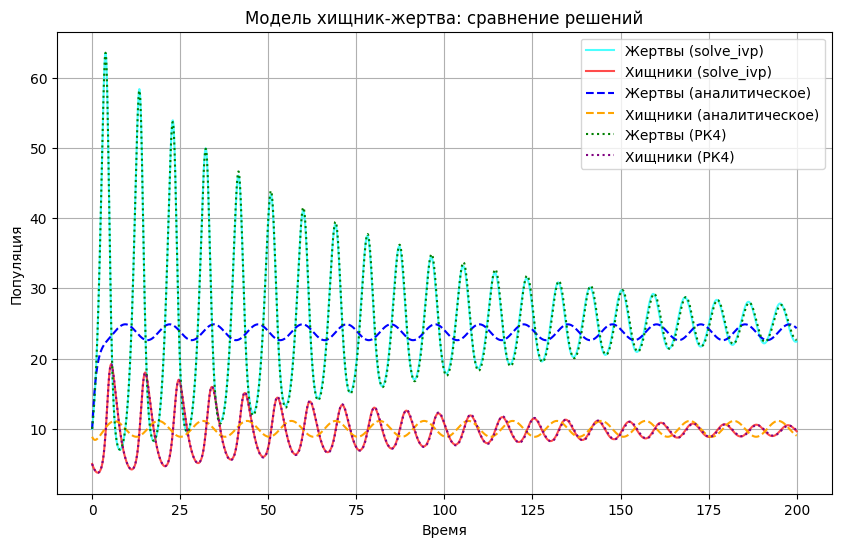

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label="Жертвы (solve_ivp)", color="cyan", alpha=.7)
plt.plot(sol.t, sol.y[1], label="Хищники (solve_ivp)", color="red", alpha=0.7)
plt.plot(t_eval, x_analytical, "--", label="Жертвы (аналитическое)", color="blue")
plt.plot(t_eval, y_analytical, "--", label="Хищники (аналитическое)", color="orange")
plt.plot(t_rk4, sol_rk4[0], ":", label="Жертвы (РК4)", color="green")
plt.plot(t_rk4, sol_rk4[1], ":", label="Хищники (РК4)", color="purple")
plt.xlabel("Время")
plt.ylabel("Популяция")
plt.title("Модель хищник-жертва: сравнение решений")
plt.legend()
plt.grid()

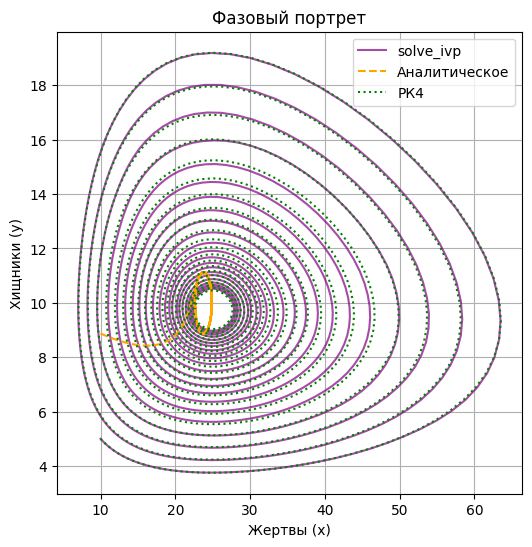

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(sol.y[0], sol.y[1], color="purple", label="solve_ivp", alpha=0.7)
plt.plot(x_analytical, y_analytical, "--", color="orange", label="Аналитическое")
plt.plot(sol_rk4[0], sol_rk4[1], ":", color="green", label="РК4")
plt.xlabel("Жертвы (x)")
plt.ylabel("Хищники (y)")
plt.title("Фазовый портрет")
plt.legend()
plt.grid()

plt.show()